In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("online_retail.csv")
df.head()
df.columns
# df.info()
df2 = df.copy()
df.describe()
df.shape

(541909, 8)

In [3]:
# Data Cleaning

df2["TotalPrice"] = df2["UnitPrice"] * df2["Quantity"]
df.isnull().sum()

# Drop Null Values Rows
df = df2.dropna(subset = ["CustomerID"]).copy()
df.isnull().sum()

# Drop Negative value Rows
df = df[df["Quantity"] > 0]
df = df[df["UnitPrice"] > 0]

df["InvoiceDate"] = pd.to_datetime(df["InvoiceDate"])


In [4]:
# Sales Analysis

# Total Revenue
Total_revenue = np.round(df["TotalPrice"].sum())
print(f"Total Revenue of Online Retail => {Total_revenue}\n")

# Month wise Revenue
df["Month"] = df["InvoiceDate"].dt.month
Total_Month_Revenue = df.groupby("Month")["TotalPrice"].sum()
print(f"Total Revenue Per Month => {Total_Month_Revenue}\n")

# Best / Worst Month Revenue
print(f"Best Month Revenue => {Total_Month_Revenue.idxmax()} : {np.round(Total_Month_Revenue[11])}")
print(f"Worst Month Revenue => {Total_Month_Revenue.idxmin()} : {np.round(Total_Month_Revenue[2])}\n")

# Daily Average Sales
df["Dates"] = df["InvoiceDate"].dt.date
Unique_Dates = df["Dates"].nunique()
Daily_Sales_Avg = np.round(Total_revenue / Unique_Dates)
print(f"Daily Sales Average Revenue => {Daily_Sales_Avg}\n")

Total Revenue of Online Retail => 8911408.0

Total Revenue Per Month => Month
1      569445.040
2      447137.350
3      595500.760
4      469200.361
5      678594.560
6      661213.690
7      600091.011
8      645343.900
9      952838.382
10    1039318.790
11    1161817.380
12    1090906.680
Name: TotalPrice, dtype: float64

Best Month Revenue => 11 : 1161817.0
Worst Month Revenue => 2 : 447137.0

Daily Sales Average Revenue => 29218.0



In [5]:
# Product Analysis

# Top 10 Best-Selling Products
Best_Selling_Prd = df.groupby("Description")["Quantity"].sum().sort_values(ascending = False).head(10)
print(f"Top 10 Best-Selling Products => \n{Best_Selling_Prd}\n")

# Top 10 Best Product Category Wise Revenue
Best_Revenue_Prd = df.groupby("Description")["TotalPrice"].sum().sort_values(ascending = False).head(10)
print(f"Top 10 Best Revenue Products => \n{Best_Revenue_Prd}\n")

# Top 1 best Revenue Product
Best_Revenue_Prd = df.groupby("Description")["TotalPrice"].sum().sort_values(ascending = False)
print(f"Top 1 Best Revenue Product = > {Best_Revenue_Prd.idxmax()} : {Best_Revenue_Prd.iloc[0]}\n")

# Top 10 Worst Selling Product
Worst_Selling_Prd = df.groupby("Description")["Quantity"].sum().sort_values(ascending = True).head(10)
print(f"Top 10 Worst Selling Products => \n{Worst_Selling_Prd}\n")

Top 10 Best-Selling Products => 
Description
PAPER CRAFT , LITTLE BIRDIE           80995
MEDIUM CERAMIC TOP STORAGE JAR        77916
WORLD WAR 2 GLIDERS ASSTD DESIGNS     54415
JUMBO BAG RED RETROSPOT               46181
WHITE HANGING HEART T-LIGHT HOLDER    36725
ASSORTED COLOUR BIRD ORNAMENT         35362
PACK OF 72 RETROSPOT CAKE CASES       33693
POPCORN HOLDER                        30931
RABBIT NIGHT LIGHT                    27202
MINI PAINT SET VINTAGE                26076
Name: Quantity, dtype: int64

Top 10 Best Revenue Products => 
Description
PAPER CRAFT , LITTLE BIRDIE           168469.60
REGENCY CAKESTAND 3 TIER              142592.95
WHITE HANGING HEART T-LIGHT HOLDER    100448.15
JUMBO BAG RED RETROSPOT                85220.78
MEDIUM CERAMIC TOP STORAGE JAR         81416.73
POSTAGE                                77803.96
PARTY BUNTING                          68844.33
ASSORTED COLOUR BIRD ORNAMENT          56580.34
Manual                                 53779.93
RABBIT N

In [6]:
# Customer Analysis

# Top 10 Customers
Top_customes = df.groupby("CustomerID")["TotalPrice"].sum().sort_values(ascending = False).head(10)
print(f"Top 10 Customer = >\n{Top_customes}\n")

# Repeat Customers vs One-Time Customers
customer_orders = df.groupby("CustomerID")["InvoiceNo"].nunique().sort_values()

one_time_cust = customer_orders[customer_orders == 1]
print(f"Total One Time Order Customer Count => {one_time_cust.shape[0]}")
more_time_cust = customer_orders[customer_orders != 1]
print(f"Total More Then One Time Order Customer Count => {more_time_cust.shape[0]}\n")

# Customer Order Frequency
print(f"Average Orders By Customers => {np.round(customer_orders.mean())}\n")

# Country Wise Distribution
Country_customers = df.groupby("Country")["CustomerID"].nunique().sort_values(ascending = False).head(10)
print(f"Top 10 Countries with Unique Customers => \n{Country_customers}\n")

Top 10 Customer = >
CustomerID
14646.0    280206.02
18102.0    259657.30
17450.0    194550.79
16446.0    168472.50
14911.0    143825.06
12415.0    124914.53
14156.0    117379.63
17511.0     91062.38
16029.0     81024.84
12346.0     77183.60
Name: TotalPrice, dtype: float64

Total One Time Order Customer Count => 1493
Total More Then One Time Order Customer Count => 2845

Average Orders By Customers => 4.0

Top 10 Countries with Unique Customers => 
Country
United Kingdom    3920
Germany             94
France              87
Spain               30
Belgium             25
Switzerland         21
Portugal            19
Italy               14
Finland             12
Austria             11
Name: CustomerID, dtype: int64



In [7]:
# Time-Based Analysis

# Which Day More Sales
df["DayOfWeek"] = df["InvoiceDate"].dt.day_name()
Sales_By_Day = df.groupby("DayOfWeek")["TotalPrice"].sum().sort_values(ascending = False)
print(f"Total Sales By Days => \n{np.round(Sales_By_Day)}\n")

# Which Month More Sales (Seasonality)
Month_Sales = np.round(df.groupby("Month")["TotalPrice"].sum().sort_values())
print(f"Obsereving This Data That In Festival Months More Products Sales => \n{Month_Sales}\n")

# Year Wise Sales
df["Year"] = df["InvoiceDate"].dt.year
year_wise_sales = np.round(df.groupby("Year")["TotalPrice"].sum())
print(f"Year Wise Sales => \n{year_wise_sales}\n")

Total Sales By Days => 
DayOfWeek
Thursday     1976859.0
Tuesday      1700635.0
Wednesday    1588336.0
Friday       1485917.0
Monday       1367146.0
Sunday        792514.0
Name: TotalPrice, dtype: float64

Obsereving This Data That In Festival Months More Products Sales => 
Month
2      447137.0
4      469200.0
1      569445.0
3      595501.0
7      600091.0
8      645344.0
6      661214.0
5      678595.0
9      952838.0
10    1039319.0
12    1090907.0
11    1161817.0
Name: TotalPrice, dtype: float64

Year Wise Sales => 
Year
2010     572714.0
2011    8338694.0
Name: TotalPrice, dtype: float64



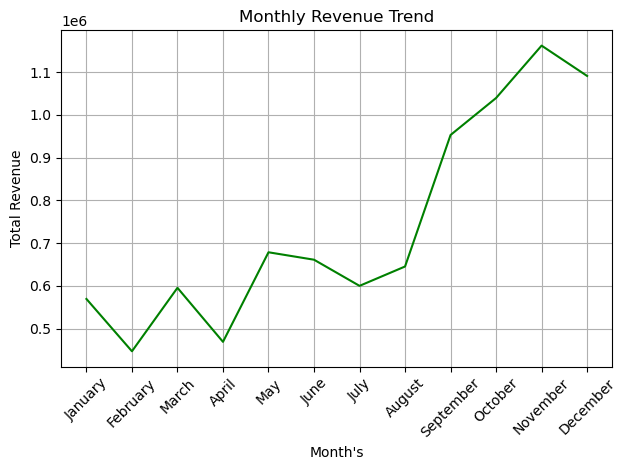

In [8]:
# Monthly Revenue Trend

value = {1 : "January", 2 : "February", 3 : "March", 4 : "April", 5 : "May", 6 : "June", 7 : "July", 8 : "August", 9 : "September", 10 : "October", 11 : "November", 12 : "December"}
df["MonthName"] = df["Month"].map(value)

Month_Revenue = np.round(df.groupby("Month")["TotalPrice"].sum().sort_index())
Month_Revenue.index = Month_Revenue.index.map(value)

sns.lineplot(
    data = Month_Revenue,
    color = "green"
)
# Month_Revenue.plot(kind = "line", marker = "o")
plt.title("Monthly Revenue Trend")
plt.xlabel("Month's")
plt.ylabel("Total Revenue")
plt.xticks(rotation = 45)
plt.tight_layout()
plt.grid()
plt.show()

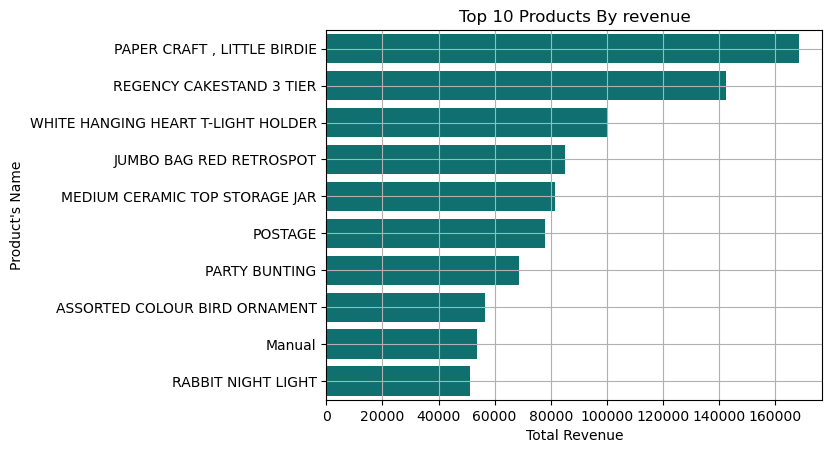

In [9]:
# Top 10 Products By revenue

best_prd = df.groupby("Description")["TotalPrice"].sum().sort_values(ascending = False).head(10)

sns.barplot(
    x=best_prd.values, 
    y=best_prd.index, 
    color='teal'
)
plt.title("Top 10 Products By revenue")
plt.xlabel("Total Revenue")
plt.ylabel("Product's Name")
plt.grid()
# plt.tight_layout()
plt.show()


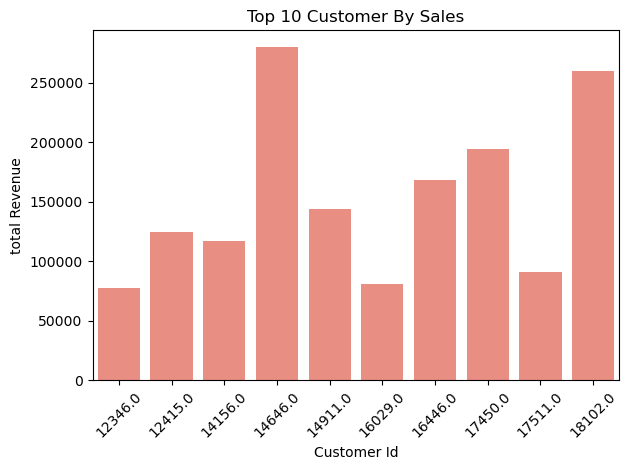

In [10]:
# Top 10 Customers By Sales

top_prd = df.groupby("CustomerID")["TotalPrice"].sum().sort_values(ascending = False).head(10)

sns.barplot(
    data = top_prd,
    color = "salmon"
)
plt.title("Top 10 Customer By Sales")
plt.xticks(rotation = 45)
plt.xlabel("Customer Id")
plt.ylabel("total Revenue")
plt.tight_layout()
# plt.grid()
plt.show()

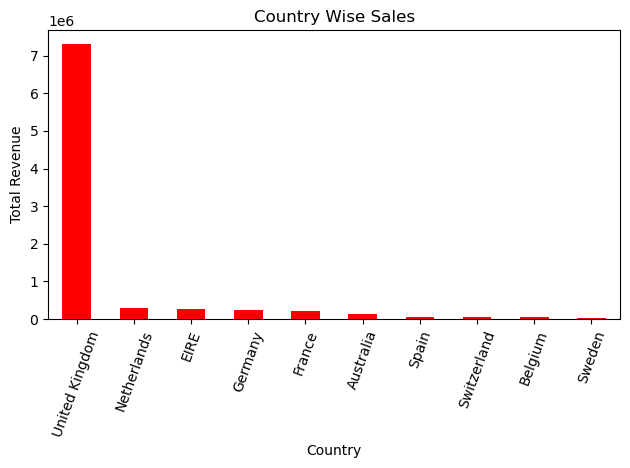

In [11]:
# Country Wise Sales

Best_country = df.groupby("Country")["TotalPrice"].sum().sort_values(ascending = False).head(10)

Best_country.plot(kind = "bar", color = "red")
plt.title("Country Wise Sales")
plt.xlabel("Country")
plt.ylabel("Total Revenue")
plt.tight_layout()
plt.xticks(rotation = 70)
plt.show()

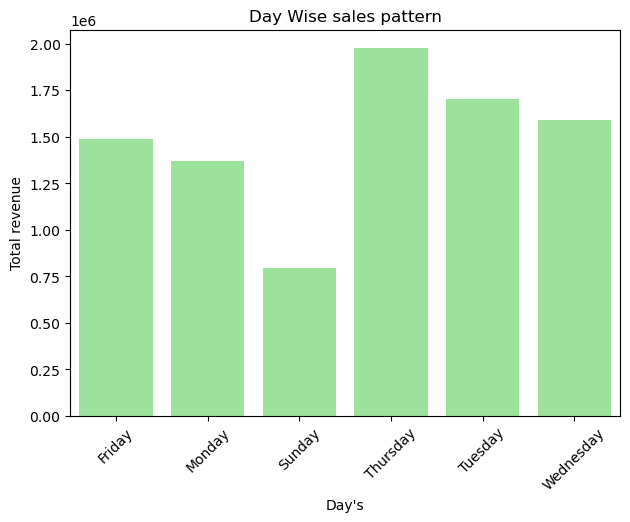

In [12]:
# Day-wise Sales Pattern

Day_wise = df.groupby("DayOfWeek")["TotalPrice"].sum()

sns.barplot(
    data = Day_wise,
   color = "lightgreen"
)
plt.title("Day Wise sales pattern")
plt.xlabel("Day's")
plt.ylabel("Total revenue")
plt.tight_layout()
plt.xticks(rotation = 45)
# plt.grid()
plt.show()

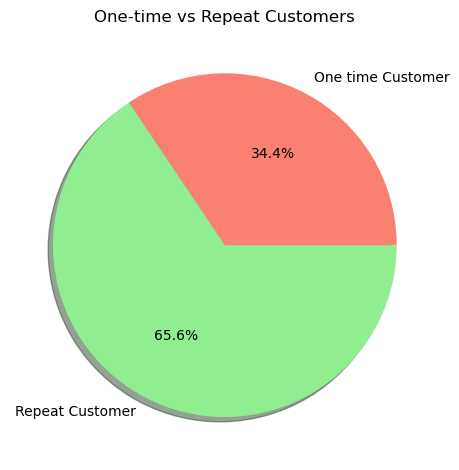

In [13]:
# One-time vs Repeat Customers

total_order = df.groupby("CustomerID")["InvoiceNo"].nunique().sort_values()
one_time_order = total_order[total_order == 1].shape[0]
more_time_order = total_order[total_order != 1].shape[0]

plt.pie([one_time_order, more_time_order],
       labels = ["One time Customer", "Repeat Customer"],
       autopct = "%1.1f%%",
        colors = ["salmon", "lightgreen"],
        shadow = True
       )
plt.title("One-time vs Repeat Customers")
plt.tight_layout()
plt.show()


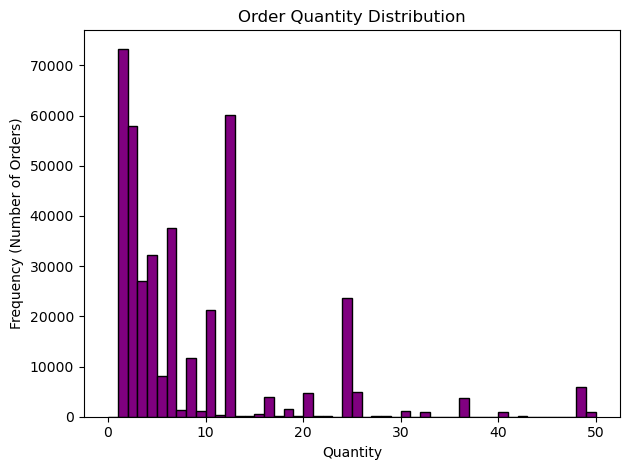

In [14]:
# Order Quantity Distribution

plt.hist(df['Quantity'], bins=50, range=(0,50), color='purple', edgecolor='black')
plt.title('Order Quantity Distribution')
plt.xlabel('Quantity')
plt.ylabel('Frequency (Number of Orders)')
plt.tight_layout()
plt.show()

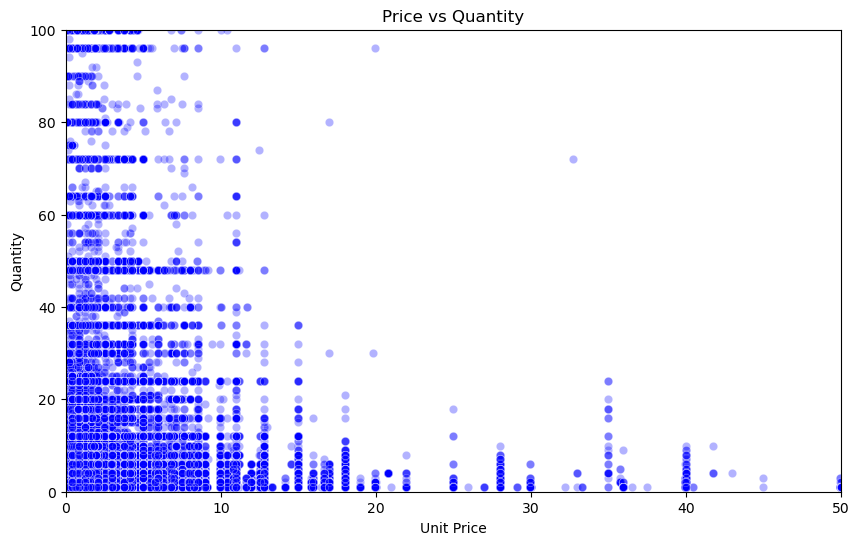

In [15]:
# Price vs Quantity

plt.figure(figsize=(10,6))
# plt.scatter(df['UnitPrice'], df['Quantity'], alpha=0.3, color='blue')
sns.scatterplot(
    data = df,
    x = "UnitPrice",
    y = "Quantity",
    color = "blue",
    alpha = 0.3
)
plt.xlim(0, 50)      # Price sirf 0-50 tak dikhao
plt.ylim(0, 100)     # Quantity sirf 0-100 tak dikhao
plt.title('Price vs Quantity')
plt.xlabel('Unit Price')
plt.ylabel('Quantity')
plt.show()

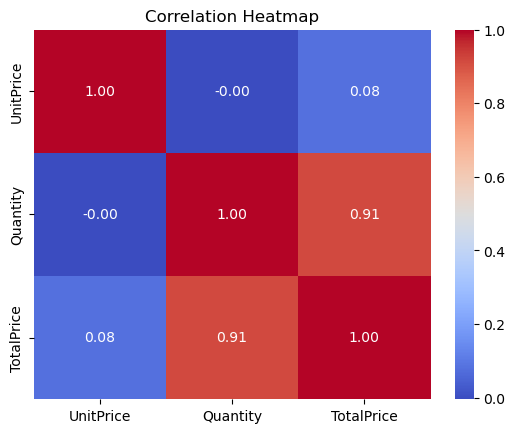

In [16]:
# Correlation Heatmap

numeric_df = df[["UnitPrice", "Quantity", "TotalPrice"]]
correlation = numeric_df.corr()

sns.heatmap(
    correlation,
    annot=True, 
    cmap='coolwarm', 
    fmt='.2f'
)
plt.title("Correlation Heatmap")
plt.show()

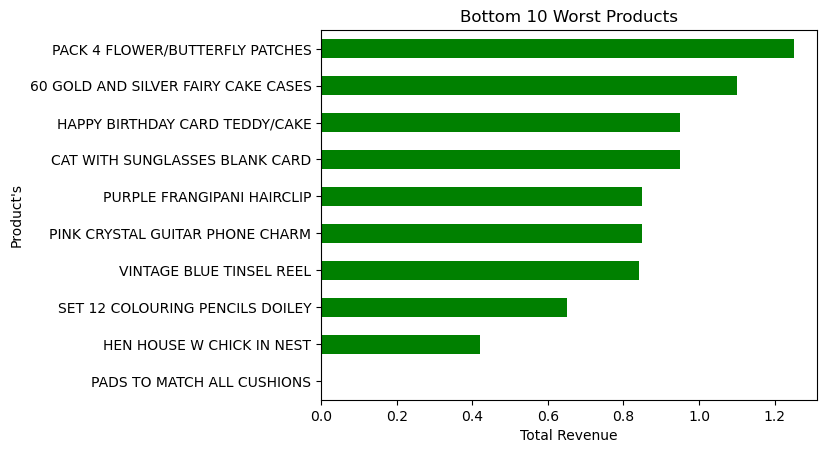

In [17]:
# Bottom 10 Products

worst_product = df.groupby("Description")["TotalPrice"].sum().sort_values(ascending = True).head(10)

worst_product.plot(kind = "barh", color = "green")
plt.title("Bottom 10 Worst Products")
plt.xlabel("Total Revenue")
plt.ylabel("Product's")
# plt.tight_layout()
plt.show()